In [ ]:
from matplotlib import ticker, pyplot as plt
from scipy import signal, fft
from numpy import pi
from tqdm.notebook import tqdm
import numpy as np

from importlib import reload
import dsp_utils as dsp
import plot_utils as plots
def reload_imported ():
    [reload(_) for _ in [dsp, plots]]
    return None

# Complete test-signal
n_0 = 2**20 # Length in samples
f_s = 48e3 # Audio sample rate

t_max = n_0 / f_s
t_range = np.arange(n_0) * 1/f_s

sins = [(53, 0.8),
        # (123, 0.3),
        # (341.2, 0.4),
        (512, 0.2),
        (1431.4, 0.3),
        (13000, 0.1),
        (6001, 0.2)]
r = lambda: np.random.random(1)[0]
signal_orig = np.sum(np.array([a * np.sin(2 * pi * f * (t_range + r())) for f, a in sins]), axis=0) * 0.6
# signal_orig = np.array([1 if (n % 100 == 0) else 0 for n in range(n_0)]).astype(float)
# signal_orig = np.random.random(n_0) * 2 - 1

signal_orig[16000:32000] = 0

print(f'Sampling-rate: {f_s/1e3:.2F} kHz')
print(f'Total signal time: {t_max:.1F} s')


n_taps = 4097
n_w = 8192 - n_taps + 1
n_dly = int(np.floor(n_taps/2))
n_fft = int(2**np.ceil(np.log2(n_w + 2 * n_dly - 1)))
n_w = int(n_fft - 2 * n_dly)

K = 16
n_hop = int(np.floor(n_w / K)) # n_w

print(f'n_taps = {n_taps}')
print(f'n_dly = {n_dly}')
print(f'n_fft = {n_fft}')
print(f'n_w = {n_w}')
print(f'n_hop = {n_hop}')

Sampling-rate: 48.00 kHz
Total signal time: 21.8 s
n_taps = 4097
n_dly = 2048
n_fft = 8192
n_w = 4096
n_hop = 256


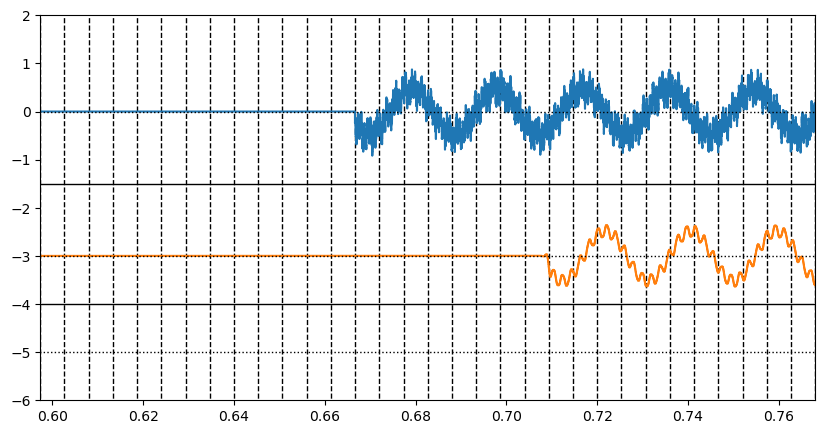

In [105]:
def processor ():
    win_fn = np.hamming(n_w)
    filt_hp = signal.firwin(n_taps, 1000, pass_zero=True, fs=f_s)
    filt_resp, _ = signal.lfilter(filt_hp, 1, np.zeros(n_fft), zi=signal.lfilter_zi(filt_hp, 1))
    # plt.plot(filt_resp)
    # plt.show()
    # prev_window = np.zeros(n_w)



    n_f = len(fft.rfft(np.zeros(n_w)))
    filt_model = signal.butter(5, 800, btype='lowpass', output='ba', fs=f_s)
    w, h = signal.freqz(*filt_model, worN = n_f, fs=f_s, include_nyquist=True)
    resp = np.abs(h).astype(np.complex128)
    inv_resp = win_fn * fft.fftshift(fft.irfft(resp))
    inv_resp_pad = np.concat((np.zeros((n_fft - n_w)//2), inv_resp, np.zeros((n_fft - n_w)//2)))
    filter_h = fft.rfft(inv_resp_pad)
    t_range = np.arange(len(inv_resp)) * 1/f_s

    n_overlap = n_fft - n_hop
    overlap_buffer = np.zeros(n_overlap)

    prev_frame = np.zeros(n_fft)
    # plt.plot(range(n_f), w)
    # plt.plot(range(n_f), w_)
    plt.show()

    plt.plot(inv_resp)
    plt.plot(inv_resp)
    plt.plot(win_fn)
    plt.plot(inv_resp_pad)
    plt.grid()
    # plt.plot(w, np.unwrap(np.angle(h)))
    # plt.plot(w, np.unwrap(np.angle(resp)))
    # plt.xscale('log')
    plt.show()

    i = 0;

    def process_window_fir (samples: np.array, n):
        global n_dly
        nonlocal i, overlap_buffer
        
        samp_padded = np.zeros(n_fft)
        samp_padded[:n] = samples

        zi = (1 if i == 0 else 0 ) * signal.lfilter_zi(filt_hp, 1) * samples[0]
        samp_filtered, zf = signal.lfilter(filt_hp, 1, samp_padded, zi=zi)
        samp_filtered[:n_overlap] += overlap_buffer
        if i < 2 or i == 5:
            t_range = np.arange(len(samp_padded))
            plt.title(i)
            # plt.vlines((0, t_range[n_dly], t_range[n], t_range[n_dly + n] ), -2, 2, lw=1, color='black')
            # plt.plot(overlap_buffer)
            # plt.plot(filt_resp[:n_dly] * samples[0])
            plt.step(t_range, samp_padded)
            plt.step(t_range, samp_filtered)
            # plt.step(t_range[:n], samples)
            # plt.step(t_range[-n_dly:], prev_window[-n_dly:])
            plt.show()

        overlap_buffer = samp_filtered[-n_overlap:]
        i += 1
        len_result = n_fft
        return len_result, samp_filtered[:]
    
    def process_window_fft (samples: np.ndarray, n: int):
        global n_dly
        nonlocal i, overlap_buffer, filter_h
        
        samp_padded = np.zeros(n_fft)
        samp_padded[n_dly:n + n_dly] = samples * win_fn

        # zi = (1 if i == 0 else 0 ) * signal.lfilter_zi(filt_hp, 1) * samples[0]
        f_range = fft.rfftfreq(n_fft, d=1/f_s)

        samp_pad_f = fft.rfft(samp_padded)
        samp_pad_f_filt = samp_pad_f * filter_h
        samp_pad_f_filt = samp_pad_f_filt * np.exp(0j*pi*f_range)
        samp_filtered = fft.fftshift(fft.irfft(samp_pad_f_filt))

        num_pad_start = n_hop

        # samp_filtered, zf = signal.lfilter(filt_hp, 1, samp_padded, zi=zi)
        # print(len(samp_filtered[:n_hop]), len(overlap_buffer))
        if i < 2 or i == 10:
            t_range = np.arange(len(samp_padded))
            plt.title(i)
            plt.vlines((0, t_range[n_dly], t_range[n], t_range[n_dly + n] ), -2, 2, lw=1, color='black')
            # plt.plot(overlap_buffer)
            # plt.plot(filt_resp[:n_dly] * samples[0])
            plt.step(t_range, samp_padded)
            plt.step(t_range, samp_filtered)
            plt.step(t_range[:n_overlap], overlap_buffer)
            # plt.step(t_range[:n], samples)
            # plt.step(t_range[-n_dly:], prev_window[-n_dly:])
            plt.show()

            plt.title(f'{i} Freqs')
            print(f_range[:20])
            plt.plot(f_range, np.abs(samp_pad_f))
            plt.plot(f_range, np.abs(samp_pad_f_filt))
            plt.xscale('log')
            plt.show()
            # 1/i

        samp_filtered[:n_overlap] += overlap_buffer
        overlap_buffer = samp_filtered[-n_overlap:]
        i += 1
        len_result = n_fft
        return len_result, samp_filtered / (K / 2)
        
    
    return process_window_fft


def process_signal (signal: np.array, n: int, n_w : int):
    
    n_slices = int(np.ceil((n - n_w) / n_hop))
    lower_idx = lambda i: int(n_hop * i)
    upper_idx = lambda i: int(min(n_hop * i + n_w, n))
    idx_slices = [(lower_idx(i), upper_idx(i)) for i in range(n_slices)]

    signal_processed = np.zeros_like(signal)
    process_window = processor()

    signal_processed_add = np.zeros_like(signal)
    for i in tqdm(range(len(idx_slices))):
        a, b = idx_slices[i]
        n_slice = b - a
        n_slice_processed, processed_slice = process_window(signal[a:b], n_slice)
        n_output_avail = min(n_slice_processed, n_0 - a)
        num_overwrite = n_slice_processed + min(0, n_output_avail - n_slice_processed)
        num_pad_start = int(np.floor((n_fft - n_w)/2))
        start_idx = a - num_pad_start

        # Overlap SAVE/DISCARD (dependece on data from previous frame)
        signal_processed[a:a + num_overwrite] = processed_slice[:num_overwrite]
        # Overlap ADD (dependece on data from next frame)
        signal_processed_add[max(start_idx, 0):start_idx + n_output_avail] += processed_slice[(-min(start_idx, 0)):n_output_avail]

    return signal_processed_add, signal_processed, idx_slices

# sig_processed_add, signal_processed, idx_slices = process_signal(signal_orig, n_0, n_w)

t_range_shifted = t_range #- n_dly/f_s
n_slices = int(np.ceil((n_0 - n_w) / n_hop))
l = K * 2
s = K * 7 * n_hop  # * (n_slices - l + 0) # int(0 * n_w + n_w/4)
e = int(s + l * n_hop)
plt.figure(figsize=(10, 5))
plt.vlines(([t_range[s] for s, e in idx_slices]), -7, 2, color='black', ls='dashed', lw=1)
plt.step(t_range[s:e], signal_orig[s:e])
plt.step(t_range_shifted[s:(e + n_w)], signal_processed[s:(e + n_w)] - 3)
# plt.step(t_range_shifted[s:(e + n_w)], sig_processed_add[s:(e + n_w)] - 5)
plt.hlines((-1.5, -4), t_range[s] - 1, t_range[e] + 1, color='black', lw=1)
plt.hlines((0, -3, -5), t_range[s] - 1, t_range[e] + 1, color='black', ls='dotted', lw=1)
plt.xlim(t_range[s], t_range[e])
plt.ylim(-6, 2)
plt.show()